# Bay Wheels Ridership Trends 2020 - 2025


Data analysis considers 2020 - 2025 since Lyft tracked data considerably differently from Ford (2017 - 2019).

2020 data is incomplete (May - December), we interpret the data time period as 'post-pandemic' since rides started to be recordedagain following the initial months of the COVID-19 shutdown.

2026 data is available but at the time of project submission it won't be representative of an entire year.

The following data exploration tries to, using ridership data alone, give contextual meaning to the mobility trends in the East Bay. Reference metrics are recorded at the scale of stations: functional form of the station based on it associated riderhsip patterns, the city the station is in, and the origin-destination pairing to understand flow between places.

For our larger story, we extract from the ridership data a bike share system becoming a conduit for first and last mile transportation, whether it is for commuting to office work or connecting from BART to an amenity destination for errands or recreation. And, using individual station case studies, we find a disparity in the distribution of bike share resources across space.

Ridership Data Analysis is composed of three parts:

1.   Data Wrangling and Cleaning
2.   Summary Statistics and Mobility Patterns
3.   Data Visualization

# Libraries and Data

In [ ]:
# Libraries
!pip install contextily

import numpy as np
import contextily
import pandas as pd
import geopandas as gpd

# For charts
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

proj_dir = os.getcwd()
data_dir = os.path.join(proj_dir, "Data")

In [ ]:
# Data Import and Composite

baywheels_2020 = pd.read_csv(os.path.join(data_dir, 'cleaned/rides by year/OaklandBerkeleyData2020.csv'))
baywheels_2021 = pd.read_csv(os.path.join(data_dir, 'cleaned/rides by year/OaklandBerkeleyData2021.csv'))
baywheels_2022 = pd.read_csv(os.path.join(data_dir, 'cleaned/rides by year/OaklandBerkeleyData2022.csv'))
baywheels_2023 = pd.read_csv(os.path.join(data_dir, 'cleaned/rides by year/OaklandBerkeleyData2023.csv'))
baywheels_2024 = pd.read_csv(os.path.join(data_dir, 'cleaned/rides by year/OaklandBerkeleyData2024.csv'))
baywheels_2025 = pd.read_csv(os.path.join(data_dir, 'cleaned/rides by year/OaklandBerkeleyData2025.csv'))

baywheels_raw = pd.concat([baywheels_2020, baywheels_2021,baywheels_2022, baywheels_2023, baywheels_2024, baywheels_2025])

# Baywheels Data Wrangling



## Initial Filtering for East Bay Cities

In [ ]:
# Function to add City name for starting and ending station ID (Applicable to Station and Ridership Data)

def get_city(station_id):
    if isinstance(station_id, str):
        if station_id.startswith('BK'):
            return 'Berkeley'
        if station_id.startswith('EM'):
            return 'Emeryville'
        if station_id.startswith('SF'):
            return 'San Francisco'
        if station_id.startswith('SJ'):
            return 'San Jose'
        elif station_id.startswith('OK'):
            return 'Oakland'
    return None

baywheels_raw['start_city'] = baywheels_raw['start_station_id'].apply(get_city) # Applying the Function
baywheels_raw['end_city'] = baywheels_raw['end_station_id'].apply(get_city)

display(baywheels_raw.head())

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,start_city,end_city
0,DEED2D13D366AB2E,docked_bike,2020-05-30 14:48:04,2020-05-30 15:42:09,Market St at 45th St,OK-E2,Market St at 45th St,OK-E2,37.834174,-122.272968,37.834174,-122.272968,casual,Oakland,Oakland
1,C6D6B300F26F9B46,docked_bike,2020-05-15 20:12:49,2020-05-15 20:14:29,Vine St at Shattuck Ave,BK-A7,Vine St at Shattuck Ave,BK-A7,37.880222,-122.269592,37.880222,-122.269592,casual,Berkeley,Berkeley
2,26A768EB3AF5366C,docked_bike,2020-05-31 18:09:50,2020-05-31 18:21:43,El Embarcadero at Grand Ave,OK-I9,Telegraph Ave at 19th St,OK-K5-1,37.808847,-122.249679,37.808702,-122.269927,member,Oakland,Oakland
3,B6C8C77A229092B3,docked_bike,2020-05-18 03:53:33,2020-05-18 04:04:58,Haste St at College Ave,BK-E10,West St at University Ave,BK-D4,37.866418,-122.253799,37.869967,-122.286533,casual,Berkeley,Berkeley
4,491CDBFB6CD7DAF2,docked_bike,2020-05-03 17:58:47,2020-05-03 17:58:47,Telegraph Ave at Carleton St,BK-G9,Ashby BART Station,BK-H6,37.862320,-122.258801,37.852477,-122.270213,member,Berkeley,Berkeley


In [ ]:
# Check for top cities, identify how many San Francisco, San Jose or Emeryville rides are still in the dataset.

display(baywheels_raw['start_city'].value_counts().head())
display(baywheels_raw['end_city'].value_counts().head())

,count
start_city,
Oakland,612273
Berkeley,421996
Emeryville,38409
San Francisco,125
San Jose,4


,count
end_city,
Oakland,611880
Berkeley,407786
Emeryville,45767
San Francisco,145
San Jose,2


In [ ]:
# Boolean mask to filter for Oakland and Berkeley - Ridership

exclude_cities = ['San Francisco', 'San Jose', 'Emeryville']
cities_to_drop = (
    baywheels_raw['start_city'].isin(exclude_cities) |
    baywheels_raw['end_city'].isin(exclude_cities)
)
baywheels_eb = baywheels_raw[~cities_to_drop] # New Ridership Dataframe with Oakland and Berkeley only

At the end of the intial filtering, we now have a ridership dataframe consisting of rides in Oakland and Berkeley only.

## Sanity Checks

In [ ]:
baywheels_eb.head() # General Dataframe Overivew

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,start_city,end_city
0,DEED2D13D366AB2E,docked_bike,2020-05-30 14:48:04,2020-05-30 15:42:09,Market St at 45th St,OK-E2,Market St at 45th St,OK-E2,37.834174,-122.272968,37.834174,-122.272968,casual,Oakland,Oakland
1,C6D6B300F26F9B46,docked_bike,2020-05-15 20:12:49,2020-05-15 20:14:29,Vine St at Shattuck Ave,BK-A7,Vine St at Shattuck Ave,BK-A7,37.880222,-122.269592,37.880222,-122.269592,casual,Berkeley,Berkeley
2,26A768EB3AF5366C,docked_bike,2020-05-31 18:09:50,2020-05-31 18:21:43,El Embarcadero at Grand Ave,OK-I9,Telegraph Ave at 19th St,OK-K5-1,37.808847,-122.249679,37.808702,-122.269927,member,Oakland,Oakland
3,B6C8C77A229092B3,docked_bike,2020-05-18 03:53:33,2020-05-18 04:04:58,Haste St at College Ave,BK-E10,West St at University Ave,BK-D4,37.866418,-122.253799,37.869967,-122.286533,casual,Berkeley,Berkeley
4,491CDBFB6CD7DAF2,docked_bike,2020-05-03 17:58:47,2020-05-03 17:58:47,Telegraph Ave at Carleton St,BK-G9,Ashby BART Station,BK-H6,37.862320,-122.258801,37.852477,-122.270213,member,Berkeley,Berkeley


In [ ]:
baywheels_eb.columns # Columns Check

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'start_city', 'end_city'],
      dtype='object')

In [ ]:
baywheels_eb.shape # Shape of dataframe, 980,716 recorded rides from 2020 - 2025 across Oakland and berkeley

(988767, 15)

In [ ]:
baywheels_eb.isnull().sum() # Null Values

# Clear lineage between station ID and city name missing values
# A distinct data entry error for rides missing start station name/ID, end station name/ID, and end coordinates

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,408
start_station_id,412
end_station_name,7096
end_station_id,7636
start_lat,0
start_lng,0


In [ ]:
# Show how many rows in the dataset have null values using Boolean Index

nan_stations = baywheels_raw[baywheels_raw['start_station_id'].isnull() | baywheels_raw['end_station_id'].isnull()]
nan_stations.head(100)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,start_city,end_city
2522,5D8D713ACAC6D3E7,docked_bike,2020-05-01 13:55:45,2020-05-01 15:16:15,21st St at 5th Ave,OK-L13,NaN,NaN,37.800459,-122.247459,NaN,NaN,casual,Oakland,None
2523,30DA3CED535D36DE,docked_bike,2020-05-31 18:38:44,2020-06-01 19:38:37,Bay Pl at Vernon St,OK-I6,NaN,NaN,37.812314,-122.260778,NaN,NaN,member,Oakland,None
2524,97CB2C30558D7C74,docked_bike,2020-05-24 19:06:50,2020-05-25 20:06:42,El Embarcadero at Grand Ave,OK-I9,NaN,NaN,37.808847,-122.249679,NaN,NaN,casual,Oakland,None
2525,5A5C03F728581CDB,docked_bike,2020-05-03 11:44:34,2020-05-04 12:44:28,El Embarcadero at Grand Ave,OK-I9,NaN,NaN,37.808848,-122.249680,NaN,NaN,casual,Oakland,None
2526,7A9B19917A602F5E,docked_bike,2020-05-14 18:01:32,2020-05-14 19:52:50,Telegraph Ave at Carleton St,BK-G9,NaN,NaN,37.862320,-122.258801,NaN,NaN,member,Berkeley,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15808,3F62A262F09AA0AE,docked_bike,2020-06-01 18:31:45,2020-06-02 17:59:16,Grand Ave at Perkins St,OK-I8,NaN,NaN,37.808893,-122.256460,NaN,NaN,member,Oakland,None
15809,D65C03B6A8655CB7,docked_bike,2020-06-13 23:24:30,2020-06-15 00:24:23,Grand Ave at Perkins St,OK-I8,NaN,NaN,37.808893,-122.256460,NaN,NaN,casual,Oakland,None
15810,CDB7E711BD09AC34,docked_bike,2020-06-12 19:39:17,2020-06-12 20:55:29,Grand Ave at Perkins St,OK-I8,NaN,NaN,37.808893,-122.256460,NaN,NaN,casual,Oakland,None
15812,03B89DB509CBA48E,docked_bike,2020-06-19 18:32:36,2020-06-20 19:32:30,Grand Ave at Perkins St,OK-I8,NaN,NaN,37.808893,-122.256460,NaN,NaN,casual,Oakland,None


In [ ]:
len(nan_stations) # 8048 Rides wihtout a start station or end station idenitifier (). Given 8,000 rides is insignificant compared to nearly a million for the entire dataframe.
# We drop all stations.

8048

In [ ]:
baywheels_eb.nunique() # Unique Values

,0
ride_id,988759
rideable_type,3
started_at,986048
ended_at,985836
start_station_name,165
start_station_id,150
end_station_name,175
end_station_id,151
start_lat,30230
start_lng,29811


In [ ]:
# Identify names shared by multiple IDs
multi_id_names = baywheels_eb.groupby('start_station_name')['start_station_id'].nunique()
multi_id_names = multi_id_names[multi_id_names > 1].sort_values(ascending=False)

print(f"Total Unique IDs: {baywheels_eb['start_station_id'].nunique()}")
print(f"Total Unique Names: {baywheels_eb['start_station_name'].nunique()}")
print("\nStation names that share multiple IDs:")

# Display the names and their associated IDs
for name in multi_id_names.index:
    ids = baywheels_eb[baywheels_eb['start_station_name'] == name]['start_station_id'].unique()
    print(f"- {name}: {list(ids)}")

Total Unique IDs: 150
Total Unique Names: 165

Station names that share multiple IDs:
- 14th St at Mandela Pkwy: ['OK-L2', 'OK-L1']
- 21st St at 5th Ave: ['OK-L13', 'OK-K10']
- 26th Ave at International Blvd: ['OK-L15', 'OK-M14']
- Channing Way at San Pablo Ave: ['BK-E2', 'BK-E3']
- College Ave at Alcatraz Ave: ['BK-A3', 'BK-I10']
- Foothill Blvd at Harrington Ave: ['OK-L17', 'OK-K17']
- Hearst Ave at Euclid Ave: ['BK-B9', 'BK-C9']
- Jack London Square: ['OK-N6', 'OK-N5']
- Market St at 45th St: ['OK-E2', 'OK-F2-2']
- Market St at 8th St: ['OK-M3', 'OK-M4']
- Market St at Brockhurst St: ['OK-H3', 'OK-F6']
- Russell St at College Ave: ['BK-H10', 'BK-G10']
- Telegraph Ave at Carleton St: ['BK-G9', 'BK-F9']
- Webster St at 2nd St: ['OK-N7', 'OK-N6']
- West Oakland BART Station: ['OK-M1', 'OK-N1']


In [ ]:
sum(baywheels_eb.duplicated()) # Duplicate Values

0

In [ ]:
print(baywheels_eb.dtypes) # Data Types

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
start_city             object
end_city               object
dtype: object


At the end of the sanity checks, the following cleaning tasks were revealed:

1.   Dealing with Missing Values
2.   Synthesize Changing Station Names with Station ID
3.   Start and End time should be Datetime
4.   Extract Year, Month, Day from start time
5.   Extract Start and End Hour, and seconds to create a trip duration column
6.   Convert any exisiting 'object' data types into categories for downstream analysis
7.   Collapse Bike Type from 3 to 2
8.   Rename Columns and Data Entries for Easier Interpretation
9.   Drop Columns not being used


Concerning missing values: gender, race, age, and the price/revenue of a trip was missing for each ride. These variables would have allowed for a richer demogrpahic analysis of who is riding bike share, and where certain demographics of riders tend to travel and cluster. Additionally, Lyft could benefit from adding more site context to their stations. Is the station in a commercial district? Is the station at a BART station?

## BayWheels Ridership Dataframe Cleaning


In [ ]:
# Missing Values
# Given that we cannot retrieve missing rides with certainty, and that these values are insignificant compared against the larger trip sample size. We drop them from the dataset.
baywheels_eb = baywheels_eb[(baywheels_eb['start_station_id'].isnull() == False) & (baywheels_eb['start_station_name'].isnull() == False) \
   & (baywheels_eb['end_station_id'].isnull() == False) & (baywheels_eb['end_station_name'].isnull() == False) & (baywheels_eb['end_city'].isnull() == False)]

In [ ]:
# Matching Start/End Station Naming Conventions and Start/End Station IDs
all_stations = pd.concat([
    baywheels_eb[['start_station_id', 'start_station_name']].rename(columns={'start_station_id': 'id', 'start_station_name': 'name'}),
    baywheels_eb[['end_station_id', 'end_station_name']].rename(columns={'end_station_id': 'id', 'end_station_name': 'name'})
])

station_index = (
    all_stations.groupby('id')['name']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)

baywheels_eb = baywheels_eb.merge(station_index, left_on='start_station_id', right_on='id', how='left')
baywheels_eb['start_station_name'] = baywheels_eb['name']
baywheels_eb.drop(columns=['id', 'name'], inplace=True)

baywheels_eb = baywheels_eb.merge(station_index, left_on='end_station_id', right_on='id', how='left')
baywheels_eb['end_station_name'] = baywheels_eb['name']
baywheels_eb.drop(columns=['id', 'name'], inplace=True)

display(baywheels_eb[['start_station_id', 'start_station_name']].drop_duplicates().head(15))

,start_station_id,start_station_name
0,OK-E2,Market St at 45th St
1,BK-A7,Vine St at Shattuck Ave
2,OK-I9,El Embarcadero at Grand Ave
3,BK-E10,Haste St at College Ave
4,BK-G9,Telegraph Ave at Carleton St
9,OK-I6,Bay Pl at Vernon St
11,OK-L4,Jefferson St at 14th St
15,OK-H9-2,Lakeshore Ave at Trestle Glen Rd
40,OK-M7,Lake Merritt BART Station
41,OK-M5,Washington St at 8th St


In [ ]:
# Verifying the 10 unique station_id and station_name gap for data validity
multi_id_names = baywheels_eb.groupby('start_station_name')['start_station_id'].nunique()
multi_id_names = multi_id_names[multi_id_names > 1].sort_values(ascending=False)
for name in multi_id_names.index:
    ids = baywheels_eb[baywheels_eb['start_station_name'] == name]['start_station_id'].unique()
    print(f"{name}: {list(ids)}")
# Confirms that matching on station name is safe for future analysis.

14th St at Mandela Pkwy: ['OK-L2', 'OK-L1']
21st St at 5th Ave: ['OK-L13', 'OK-K10']
26th Ave at International Blvd: ['OK-L15', 'OK-M14']
Channing Way at San Pablo Ave: ['BK-E2', 'BK-E3']
College Ave at Alcatraz Ave: ['BK-A3', 'BK-I10']
Foothill Blvd at Harrington Ave: ['OK-L17', 'OK-K17']
Market St at 45th St: ['OK-E2', 'OK-F2-2']
Russell St at College Ave: ['BK-H10', 'BK-G10']
Telegraph Ave at Carleton St: ['BK-G9', 'BK-F9']
Webster St at 2nd St: ['OK-N7', 'OK-N6']


In [ ]:
# Data and Time Conversions
baywheels_eb['started_at'] = pd.to_datetime(baywheels_eb['started_at'], format='mixed')
baywheels_eb['ended_at'] = pd.to_datetime(baywheels_eb['ended_at'], format='mixed')

# Date/Time Extraction
baywheels_eb['year'] = baywheels_eb['started_at'].dt.year
baywheels_eb['month'] = baywheels_eb['started_at'].dt.month
baywheels_eb['weekday'] = baywheels_eb['started_at'].dt.weekday # Monday = 0 Sunday = 6
baywheels_eb['start_hour'] = baywheels_eb['started_at'].dt.hour
baywheels_eb['end_hour'] = baywheels_eb['ended_at'].dt.hour
baywheels_eb['seconds'] = ((baywheels_eb['ended_at'] - baywheels_eb['started_at']) / pd.Timedelta(seconds=1)).abs()
baywheels_eb['trip_duration'] = (baywheels_eb['seconds']/60).round(2)

In [ ]:
# Renaming Columns for easier Readability
baywheels_eb = baywheels_eb.rename(columns={"rideable_type": "bike_type", "member_casual": "membership"})
baywheels_eb.drop(['started_at', 'ended_at', 'seconds'], axis=1, inplace=True, errors='ignore')

# Cleaning Data Entries
baywheels_eb["bike_type"] = baywheels_eb["bike_type"].str.strip("_bike")
baywheels_eb["bike_type"] = baywheels_eb["bike_type"].str.replace("docked", "classic") # "Docked" was the only available option prior to the introduction of E-Bikes (2024)
baywheels_eb["bike_type"] = baywheels_eb["bike_type"].str.replace("lectric", "electric")

# Data Types
baywheels_eb['membership'] = baywheels_eb['membership'].astype('category')
baywheels_eb['bike_type'] = baywheels_eb['bike_type'].astype('category')
baywheels_eb['start_city'] = baywheels_eb['start_city'].astype('category')
baywheels_eb['end_city'] = baywheels_eb['end_city'].astype('category')
baywheels_eb['year'] = baywheels_eb['year'].astype('category')
baywheels_eb['month'] = baywheels_eb['month'].astype('category')
baywheels_eb['weekday'] = baywheels_eb['weekday'].astype('category')

## BayWheels First Trip Since 2020



*   For downstream analysis and comparison, we look for stations that were installed post-pandemic to track Berkeley and Oakland's progress on bike share station goals while accounting for spikes in the ridership trends.



In [ ]:
# Station First Trips
station_first_trip = baywheels_eb.assign(
    year_int=baywheels_eb['year'].astype(int),
    month_int=baywheels_eb['month'].astype(int)
).groupby(['start_station_id', 'start_station_name', 'start_city']).agg({
    'year_int': 'min', # Conversion of date-time categories back to int for filtering
    'month_int': 'min'
}).reset_index()

station_first_trip.columns = ['station_id', 'station_name', 'city', 'first_year', 'first_month']

new_eb_stations_21_25 = station_first_trip[station_first_trip['first_year'].isin([2021, 2022, 2023, 2024, 2025])]
expansion_station = new_eb_stations_21_25.groupby(['first_year', 'city'], observed=True).size().unstack(fill_value=0)

print()
display(expansion_station)
print()
display(new_eb_stations_21_25.sort_values(['first_year', 'first_month', 'city', 'station_name']))

# Most likely a data entry/recordation inconsistency, but 2025 (under the MTC expansion program) was the first time both cities installed stations consistently over the course
# of a year. Prior to that, stations were installed over winter, with first trips occuring in January.

# It also likely the case that some of the stations appearing with a 'first' ride in 2021 had their stations shut down during 2020 due to operation costs.

/tmp/ipykernel_3183/2728563652.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby(['start_station_id', 'start_station_name', 'start_city']).agg({


city,Berkeley,Oakland
first_year,,
2021.0,3,8
2022.0,0,3
2024.0,0,1
2025.0,2,15


,station_id,station_name,city,first_year,first_month
5410,BK-E3,Channing Way at San Pablo Ave,Berkeley,2021.0,1.0
2636,BK-C9,Euclid Ave at Hearst Ave,Berkeley,2021.0,1.0
8088,BK-F9,Telegraph Ave at Carleton St,Berkeley,2021.0,1.0
31935,OK-L1,14th St at Mandela Pkwy,Oakland,2021.0,1.0
28019,OK-K10,21st St at 5th Ave,Oakland,2021.0,1.0
38107,OK-M14,26th Ave at International Blvd,Oakland,2021.0,1.0
28965,OK-K17,Foothill Blvd at Harrington Ave,Oakland,2021.0,1.0
41319,OK-N5,Jack London Square,Oakland,2021.0,1.0
18109,OK-F2-2,Market St at 45th St,Oakland,2021.0,1.0
39391,OK-M4,Market St at 8th St,Oakland,2021.0,1.0


## Dataframe Check

In [ ]:
baywheels_eb.head()

,ride_id,bike_type,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,membership,start_city,end_city,year,month,weekday,start_hour,end_hour,trip_duration
0,DEED2D13D366AB2E,classic,Market St at 45th St,OK-E2,Market St at 45th St,OK-E2,37.834174,-122.272968,37.834174,-122.272968,casual,Oakland,Oakland,2020,5,5,14,15,54.08
1,C6D6B300F26F9B46,classic,Vine St at Shattuck Ave,BK-A7,Vine St at Shattuck Ave,BK-A7,37.880222,-122.269592,37.880222,-122.269592,casual,Berkeley,Berkeley,2020,5,4,20,20,1.67
2,26A768EB3AF5366C,classic,El Embarcadero at Grand Ave,OK-I9,Telegraph Ave at 19th St,OK-K5-1,37.808847,-122.249679,37.808702,-122.269927,member,Oakland,Oakland,2020,5,6,18,18,11.88
3,B6C8C77A229092B3,classic,Haste St at College Ave,BK-E10,West St at University Ave,BK-D4,37.866418,-122.253799,37.869967,-122.286533,casual,Berkeley,Berkeley,2020,5,0,3,4,11.42
4,491CDBFB6CD7DAF2,classic,Telegraph Ave at Carleton St,BK-G9,Ashby BART,BK-H6,37.862320,-122.258801,37.852477,-122.270213,member,Berkeley,Berkeley,2020,5,6,17,17,0.00


In [ ]:
new_eb_stations_21_25.head()

,station_id,station_name,city,first_year,first_month
2636,BK-C9,Euclid Ave at Hearst Ave,Berkeley,2021.0,1.0
5410,BK-E3,Channing Way at San Pablo Ave,Berkeley,2021.0,1.0
8088,BK-F9,Telegraph Ave at Carleton St,Berkeley,2021.0,1.0
8338,BK-G10,Russell St at College Ave,Berkeley,2025.0,8.0
11014,BK-I10,College Ave at Alcatraz Ave,Berkeley,2025.0,8.0


The new BayWheels dataframe is filtered for Berkeley and Oakland, with more readable and organized column names and data types. Duplicate names under different conventions and associated station IDs were accounted for with a matching script. The ride start and ride end timestamp was disassembled to produce separate columns for year, month, weekday, start hour, end hour, and trip duration in minutes.

The first east bay stations were installed in 2017; however, there have been recent expansion efforts and the occasional marquee station installation. The first trip recorded script helps us verify which stations in the dataframe were installed post-2020. There is a bit of an anomaly with this framing as the return states new stations prior to the 2025 expansion saw first trips in January. We aren't able to verify on official websites when a station was installed, though it does lead to questions concerning the logistics of station installation. The first trip/installation date helps give us more context for why some stations might have significantly lower volumes than other stations, or why the total trips across the system see spikes in ridership over time.

# Baywheels Summary Statistics and Trends



1.   Trip Duration: Derived vs Non-Derived Trip Share
2.   Ridership Volume: E-Bike Technology, Station Density, Station Siting within Land Use contexts, and How a Staition Functions.
3.   Member vs. Casual: The Effects of Pricing Policy.
4.   Weekday vs. Weekend & Time of Day: Further evidence of E-Bike, Bike Network Improvement, Station Density/siting, and Return to Work commuting effects.



## Trip Duration

In [ ]:
# Summary Statistics with 5% share of values.

display(baywheels_eb.trip_duration.describe()) # Average trip time is 8.15 minutes, outlier of 0 is established. Most trips range from 5 to 14 minutes.
print()
display(baywheels_eb.trip_duration.quantile(0.95)) # 95 % of trips are under 36.5 minutes. Helps with contextualizing max outliers.
display(baywheels_eb.trip_duration.quantile(0.05)) # 95% of trips are above ~ 2.5 minutes. Helps with contextualizing min outliers.

,trip_duration
count,980716.000000
mean,14.854503
std,137.229523
min,0.000000
25%,5.030000
50%,8.150000
75%,13.970000
max,59051.100000


np.float64(36.5)

np.float64(2.61)

In [ ]:
# Dropping corrupted trip outliers (False Starts, Stolen Bikes, etc.)
baywheels_eb = baywheels_eb[(baywheels_eb['trip_duration'] >= 2) & (baywheels_eb['trip_duration'] <= 180)] # 2 minutes and 3 hours. The researcher personally has taken a recreational trip
# that lasted 3 hours around Boston, this is a legitimate ride if someone perhaps tried doing a Bay Trail loop

display(baywheels_eb['trip_duration'].describe()) # Statistical summary from unfiltered ridership data is still the same, but data distribution is more reflective of realistic rides

,trip_duration
count,952661.000000
mean,12.509299
std,13.973992
min,2.000000
25%,5.220000
50%,8.300000
75%,14.100000
max,180.000000


In [ ]:
# Trip Duration Median, 25% and 75% year by year - Classic and Electric
# Gives us a better understanding of how trip duration changed since the pandemic
trip_quantiles = (baywheels_eb.groupby('year', observed=True)['trip_duration']
                    .quantile([0.25, 0.50, 0.75])
                    .unstack()
                    .rename(columns={0.25: 'p25', 0.50: 'median', 0.75: 'p75'})
                    .round(1))
trip_quantiles['IQR'] = trip_quantiles['p75'] - trip_quantiles['p25']

display(trip_quantiles)
# The median drops dramatically after 2020, with the outer limits of trips coming close to under 10 minutes.
# E-Bike Effect in 2024 is not reflective of true travel behavior but accelerated technology reducing trip duration.

,p25,median,p75,IQR
year,,,,
2020,7.5,13.4,24.9,17.4
2021,6.5,10.7,18.7,12.2
2022,6.1,9.7,16.0,9.9
2023,5.6,8.9,14.7,9.1
2024,4.8,7.4,12.0,7.2
2025,4.6,6.9,11.0,6.4


In [ ]:
# Trip Duration Median, 25% and 75% year by year - Classic only
classic_bw = baywheels_eb[baywheels_eb['bike_type'] == 'classic'].copy()
classic_trip_quantiles = (classic_bw.groupby('year', observed=True)['trip_duration']
                    .quantile([0.25, 0.50, 0.75])
                    .unstack()
                    .rename(columns={0.25: 'p25', 0.50: 'median', 0.75: 'p75'})
                    .round(1))
classic_trip_quantiles['IQR'] = classic_trip_quantiles['p75'] - classic_trip_quantiles['p25']

display(classic_trip_quantiles)
# The plateau of the IQR following 2022 reveals system users beginning to show predictable travel behavior.
# More honest reflection of travel behavior across the system year by year

,p25,median,p75,IQR
year,,,,
2020,7.5,13.4,24.9,17.4
2021,6.5,10.7,18.7,12.2
2022,6.1,9.7,16.0,9.9
2023,5.6,8.9,14.7,9.1
2024,5.3,8.3,13.5,8.2
2025,5.2,8.2,13.5,8.3


In [ ]:
# Counting of Classic rides only using the 15 minute threshold established from the prior table
classic_bw['time_class'] = 'non-derived'
classic_bw.loc[classic_bw['trip_duration'] <= 15, 'time_class'] = 'derived' # 20 minutes as an externally applied cut-off for bike trips in non-derived circumstances

display(classic_bw['time_class'].value_counts())

# 60 % of classic rides are derived across all years, skewed by 2020 and 2021

,count
time_class,
derived,456655
non-derived,177227


In [ ]:
# Year-by-year Derived/Non-Derived Rides - Using Classic Rides across all years
derive_yearly = (classic_bw.groupby('year', observed=True)
          .agg(total=('time_class', 'count'),
               derived=('time_class', lambda x: (x == 'derived').sum()),
               non_derived=('time_class', lambda x: (x == 'non-derived').sum())))

derive_yearly['derived_share'] = (derive_yearly['derived'] / derive_yearly['total']).round(2)
derive_yearly['non_derived_share'] = (derive_yearly['non_derived'] / derive_yearly['total']).round(2)

display(derive_yearly)

# More accurate reflection of the share over time. System from 2020 - 2025 demonstrates a shift towards derived trips on bike share.
# We can assume given the quantile metrics for E-Bike rides, that the derived share might be even higher than what is purported here.

,total,derived,non_derived,derived_share,non_derived_share
year,,,,,
2020,67087,36780,30307,0.55,0.45
2021,113279,75229,38050,0.66,0.34
2022,143562,103788,39774,0.72,0.28
2023,128324,97288,31036,0.76,0.24
2024,97460,77023,20437,0.79,0.21
2025,84170,66547,17623,0.79,0.21


In [ ]:
# Derived Ridership per station - Based on the Classic bike dataframe
derived_station = (classic_bw.groupby(['start_station_name', 'year'], observed=True)
                  .agg(total=('time_class', 'count'),
                       derived=('time_class', lambda x: (x == 'derived').sum())))
derived_station['derived_share'] = (derived_station['derived']
                                       / derived_station['total'])

# Wide form
station_derive_wide = (derived_station['derived_share']
                     .unstack('year')
                     .round(2))

# Classic Bike Volume Sorting
classic_vol = classic_bw.groupby('start_station_name', observed=True).size()
station_derive_wide = station_derive_wide.reindex(
    classic_vol.sort_values(ascending=False).index
)

display(station_derive_wide.head(140))

year,2020,2021,2022,2023,2024,2025
start_station_name,,,,,,
MacArthur BART Station,0.66,0.82,0.85,0.89,0.92,0.90
Bancroft Way at Telegraph Ave,0.64,0.73,0.75,0.80,0.82,0.78
El Embarcadero at Grand Ave,0.33,0.52,0.59,0.62,0.70,0.68
Downtown Berkeley BART,0.70,0.67,0.71,0.79,0.82,0.80
19th Street BART Station,0.73,0.83,0.87,0.91,0.92,0.92
...,...,...,...,...,...,...
11th Ave at 19th St,NaN,NaN,NaN,NaN,NaN,0.67
E 18th St at 4th Ave,NaN,NaN,NaN,NaN,NaN,0.56
Fruitvale Ave at MacArthur Blvd,NaN,NaN,NaN,NaN,NaN,0.33


Trip Duration Variables and Dataframes:



*   Trip Quantiles: proportions and statistical summary of trip duration metrics using all trips from 2020-2025
*  classic_bw: dataframe filtering for rides using classic bikes only
*   Classic Trip Quantiles: proportions and statistical summary of trip duration metrics based on classic bikes only
* derived_yearly: dataframe using the 15 minute derived/non-derived trip threshold column classification to show the aggregate comparison of trip utility over time.
* station_derived: dataframe using a similar logic for derived_yearly to compute the ride utility share per station per year.

Trip Duration EDA Insights:

The introduction of electric bikes as a mode choice in 2024 had a clear impact on ridership metrics as the median trip duration (6.9) deviates noticeably from the classic bike median trip duration (8.2) starting that year. What the classic quantiles show is BayWheels in the East Bay maturing from pandemic novelty for leisure rides towards a functional part of the transportation system. In addition to commuter connections, it's a surrogate for the success of recent streetscape improvement projects, bike lane additions, and the return of in-person activity along amenity corridors. By using the derived/non-derived trip metric, we can trace over time which stations have shifted into a functional commuter station (El Embarcadero) and which stations are still serving both needs (9th and Heinz, 5th and Deleware, 4th and Addison).  



## Ridership Volume

In [ ]:
# Station Ridership Volume Summary
start_vol = baywheels_eb['start_station_name'].value_counts()
end_vol = baywheels_eb['end_station_name'].value_counts()
total_station_rides = start_vol.add(end_vol, fill_value=0)

display(total_station_rides.describe())
# Highly Skewed to the right, use the median, or total volume for comparisons.
# Outlier of 26 rides for the lowest station (installed 2025)
# Most stations recorded between 3,932 and 20,039 rides.
# With an average of 13,632 rides. And a median of 9,923
# A handful of high-traffic hub stations are pulling the average up, while most stations see more moderate usage

,count
count,140.000000
mean,13609.442857
std,12437.818344
min,26.000000
25%,3905.250000
50%,9911.500000
75%,20013.000000
max,61163.000000


In [ ]:
# Stations with trips in the 75% quantile range
vol_75_threshold = total_station_rides.quantile(0.75)
top_75_pct_stations = total_station_rides[total_station_rides > vol_75_threshold].sort_values(ascending=False)
print(f"75th Percentile Volume Threshold: {vol_75_threshold:,.2f} rides")
print(f"Number of stations in the top 25%: {len(top_75_pct_stations)}")
print()
display(top_75_pct_stations)

# Predictable pattern of BART connections, UC Berkeley, and amenity destiations like El Embarcadero & Telegraph and 49th

75th Percentile Volume Threshold: 20,013.00 rides
Number of stations in the top 25%: 35



,count
MacArthur BART Station,61163
Bancroft Way at Telegraph Ave,56647
Downtown Berkeley BART,54643
19th Street BART Station,45178
El Embarcadero at Grand Ave,44997
Bay Pl at Vernon St,39004
Bancroft Way at College Ave,38740
Rockridge BART,36244
Grand Ave at Perkins St,36069
Lake Merritt BART Station,35223


In [ ]:
# Median Ridership per City
station_summary = pd.DataFrame(total_station_rides).rename(columns={'count': 'total_rides'})
station_summary = station_summary.merge(
    baywheels_eb[['start_station_name', 'start_city']].drop_duplicates('start_station_name'),
    left_index=True,
    right_on='start_station_name'
)
city_median_volume = station_summary.groupby('start_city', observed=True)['total_rides'].median().sort_values(ascending=False)
display(city_median_volume)
# Shows how Berkeley stations tend to be centered on facility UC student commuting as their median ride totals are near the overall 75% quantile.

,total_rides
start_city,
Berkeley,18627.5
Oakland,6697.0


In [ ]:
# Comparing the Absolute Value Distribution across the two cities.
city_metrics = station_summary.groupby('start_city', observed=True).agg(
    total_stations=('total_rides', 'count'),
    absolute_ridership=('total_rides', 'sum')
).sort_values('absolute_ridership', ascending=False)

display(city_metrics)
# Oakland's responsibility to cover a larger geographic area results in a lower median ridership, too.

,total_stations,absolute_ridership
start_city,,
Oakland,102,1138032
Berkeley,38,767290


In [ ]:
# Total Rides per year by station - for downstream analysis and reference metrics in the report/publication
starts_yr = (baywheels_eb.groupby(['start_station_name', 'year']).size()
             .rename('starts')
             .rename_axis(['station_name', 'year']))
ends_yr   = (baywheels_eb.groupby(['end_station_name', 'year']).size()
             .rename('ends')
             .rename_axis(['station_name', 'year']))
# Long form
station_vol_long = pd.concat([starts_yr, ends_yr], axis=1).fillna(0).astype(int)
station_vol_long['total'] = station_vol_long['starts'] + station_vol_long['ends']
station_vol_long = station_vol_long.reset_index()

# Wide Form
station_vol_wide = (station_vol_long
                     .pivot(index='station_name', columns='year', values='total')
                     .fillna(0).astype(int))
station_vol_wide.columns.name = None

year_cols = [col for col in station_vol_wide.columns if isinstance(col, int) or str(col).isdigit()]
station_vol_wide['total_all_years'] = station_vol_wide[year_cols].sum(axis=1)
station_vol_wide['avg_ride'] = (station_vol_wide[year_cols].mean(axis=1)).round(0)
station_vol_wide['growth_pct'] = ((station_vol_wide[2025] - station_vol_wide[2021]) / station_vol_wide[2021] * 100).round(2)
station_year_wide = station_vol_wide.sort_values('avg_ride', ascending=False)

display(station_year_wide.head(150))

# Reveals marquee station case study stations: El Embarcadero/Addison & 4th, Raimondi Park, Piedmont and 40th, and the slow integration of East Oakland stations with the rest of the network.
# Telegraph Avenue complete streets case study, ridership explodes along the corridor following the completion of project segments.

/tmp/ipykernel_3183/3239289219.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  starts_yr = (baywheels_eb.groupby(['start_station_name', 'year']).size()
/tmp/ipykernel_3183/3239289219.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ends_yr   = (baywheels_eb.groupby(['end_station_name', 'year']).size()


,2020,2021,2022,2023,2024,2025,total_all_years,avg_ride,growth_pct
station_name,,,,,,,,,
MacArthur BART Station,1886,5775,10260,9386,14264,19592,61163,10194.0,239.26
Bancroft Way at Telegraph Ave,2834,5811,8119,6639,13573,19671,56647,9441.0,238.51
Downtown Berkeley BART,2526,4975,7907,7617,12070,19548,54643,9107.0,292.92
19th Street BART Station,1706,3724,6660,7711,11101,14276,45178,7530.0,283.35
El Embarcadero at Grand Ave,5035,6596,7435,6831,8464,10636,44997,7500.0,61.25
...,...,...,...,...,...,...,...,...,...
11th Ave at 19th St,0,0,0,0,0,395,395,66.0,inf
Fruitvale Ave at MacArthur Blvd,0,0,0,0,0,157,157,26.0,inf
E 18th St at 4th Ave,0,0,0,0,0,59,59,10.0,inf


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
# Origin-Destination Pairs - Downstream Analysis or reference metrics
# A further data exploration pathway to see where the trips are going based on the total aggregates computed above
min_total = 1
baywheels_od = (baywheels_eb.groupby(['start_station_name', 'end_station_name', 'year'])
           .size()
           .unstack('year', fill_value=0)
           .astype(int))
year_cols = list(baywheels_od.columns)
baywheels_od['total'] = baywheels_od[year_cols].sum(axis=1)
baywheels_od = baywheels_od[baywheels_od['total'] >= min_total].reset_index()

baywheels_od = (baywheels_od
           .merge(baywheels_eb[['start_station_name', 'start_city']]
                  .drop_duplicates('start_station_name'),
                  on='start_station_name', how='left')
           .merge(baywheels_eb[['end_station_name', 'end_city']]
                  .drop_duplicates('end_station_name'),
                  on='end_station_name', how='left'))

cols = (['start_station_name',
         'start_city',
         'end_station_name',
         'end_city']
        + year_cols + ['total'])
baywheels_od = (baywheels_od[cols]
           .sort_values('total', ascending=False)
           .reset_index(drop=True))
baywheels_od.insert(0, 'rank', baywheels_od.index + 1)

display(baywheels_od.head(100))

# Outstanding OD-Pairs:
# Raimondi Park <-> West Oakland BART - Station opened around the same time Prescott Market opened, and the Ballers played games at Raimondi.
# Example of a station that connects first/last mile with a BART station, but is likely amenity-based instead of for 9-5 commuting.
# 40th and Piedmont <-> MacArthur BART - Prior to its opening in 2022, no other baywheels station directly served Piedmont Avenue from a transit connection
# Another example of a station that connects 9-5 trips from a dense residential area, and also connects amenity-based trips to a corridor that previously had no connection
# El Embarcadero and Addison/4th Loop Declines - further evidence of the post-pandemic shift from leisure rides to rides more centered on utilitarian work commutes or time-sensitive
# amenity destination based trips
# Downtown Berkeley BART <-> Bancroft and College Avenue - evidence of a station that experienced exponential growth following an infrastructure improvement.
# A cycletrack from downtown berkeley along Bancroft was completed in 2024, and as a result ridership shot up from the 200s to the 1000s

# Across the top 30 O-D pairs, a BART connection was present in 24 of the pairs. The other 6 are the two aforementioned loops, and UC Berkeley campus connections.

/tmp/ipykernel_3183/3764763420.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  baywheels_od = (baywheels_eb.groupby(['start_station_name', 'end_station_name', 'year'])


,rank,start_station_name,start_city,end_station_name,end_city,2020,2021,2022,2023,2024,2025,total
0,1,Bay Pl at Vernon St,Oakland,19th Street BART Station,Oakland,124,144,405,1111,1217,1403,4404
1,2,Grand Ave at Perkins St,Oakland,19th Street BART Station,Oakland,76,377,691,589,1054,1362,4149
2,3,19th Street BART Station,Oakland,Bay Pl at Vernon St,Oakland,117,167,401,835,1064,1473,4057
3,4,19th Street BART Station,Oakland,Grand Ave at Perkins St,Oakland,78,306,561,696,939,1330,3910
4,5,Telegraph Ave at 49th St,Oakland,MacArthur BART Station,Oakland,21,176,600,622,1150,1168,3737
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Madison St at 17th St,Oakland,Madison St at 17th St,Oakland,344,251,129,87,93,179,1083
96,97,Lake Merritt BART Station,Oakland,Lake Merritt BART Station,Oakland,94,243,317,260,81,83,1078
97,98,Parker St at Fulton St,Berkeley,Bancroft Way at College Ave,Berkeley,6,97,68,54,228,624,1077
98,99,Derby St at College Ave,Berkeley,Downtown Berkeley BART,Berkeley,18,42,146,59,245,562,1072


In [ ]:
# Cleaning of the O-D Pairings for less storage
# Based on the data summary, drop pairs below 11.
baywheels_od = baywheels_od[baywheels_od['total'] >= 11].reset_index(drop=True)
baywheels_od['rank'] = baywheels_od.index + 1

display(baywheels_od.describe().round(3)) # Still  over 7508 pairs!
# Lots of potential for a disaggregate analysis of Non-Bart, Non-Amenity Destination trips with outlier O-D pairings.

,rank,2020,2021,2022,2023,2024,2025,total
count,7501.000,7501.000,7501.000,7501.000,7501.000,7501.000,7501.000,7501.000
mean,3751.000,8.548,14.622,18.653,16.711,26.464,38.165,123.163
std,2165.497,23.099,30.679,41.395,41.925,63.276,89.879,257.157
min,1.000,0.000,0.000,0.000,0.000,0.000,0.000,11.000
25%,1876.000,0.000,1.000,2.000,1.000,3.000,5.000,19.000
50%,3751.000,2.000,5.000,6.000,5.000,8.000,12.000,41.000
75%,5626.000,8.000,15.000,17.000,14.000,23.000,33.000,114.000
max,7501.000,858.000,787.000,691.000,1111.000,1217.000,1473.000,4404.000


Ridership Volume Variables and Dataframes:



*   station_year_wide: dataframe capturing ridership volume per station across all active years in the Lyft tracking system, additional columns for average and growth percentage are added as additional reference metrics. Both have their caveats for stations installed after 2020 and 2021.
*   baywheels_od: origin-destination pairs (bi-directional) across the entire system from 2020 - 2025.

Ridership Volume Insights:




## Rider Status

In [ ]:
# Rider Status by Year
membership_trends = baywheels_eb.groupby(['year', 'membership']).size().unstack(fill_value=0)

membership_trends['total'] = membership_trends.sum(axis=1)
membership_trends['member_pct'] = (membership_trends['member'] / membership_trends['total'] * 100).round(1)
membership_trends['casual_pct'] = (membership_trends['casual'] / membership_trends['total'] * 100).round(1)

display(membership_trends)

# Casual Rides were consistently around 60k before dropping by about 12k in 2023 (pricing?)
# Member rides grew substantially since 2020, becoming a 73 to 26 percent split.

/tmp/ipykernel_3183/321549875.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  membership_trends = baywheels_eb.groupby(['year', 'membership']).size().unstack(fill_value=0)


membership,casual,member,total,member_pct,casual_pct
year,,,,,
2020,36374,30713,67087,45.8,54.2
2021,61442,51837,113279,45.8,54.2
2022,65471,78091,143562,54.4,45.6
2023,47735,80589,128324,62.8,37.2
2024,62594,140962,203556,69.2,30.8
2025,79461,217392,296853,73.2,26.8


In [ ]:
# Average Ride Duration by Rider Status per Year
duration_trends = baywheels_eb.groupby(['year', 'membership'], observed=True)['trip_duration'].mean().unstack()

display(duration_trends.round(2))

# Reflects multiple trends: return to commuting to the office for work, increase in station density, and land use patterns around stations.

membership,casual,member
year,,
2020,23.85,15.41
2021,18.63,12.72
2022,16.90,11.70
2023,16.48,10.90
2024,13.69,9.21
2025,12.99,8.73


In [ ]:
# BART vs Non-BART Ridership Trends by Membership
# Filtering logic: if a trip either starts or ends with a BART station
bart_start = baywheels_eb['start_station_name'].str.contains('BART', case=False, na=False)
bart_end = baywheels_eb['end_station_name'].str.contains('BART', case=False, na=False)
baywheels_eb['bart_trip'] = (bart_start | bart_end).map({True: 'BART', False: 'Non-BART'})

bart_trips_yr = (baywheels_eb.groupby(['year', 'bart_trip', 'membership'])
                 .size().rename('trips').reset_index())

bart_trip_counts = bart_trips_yr.pivot_table(
    index='year', columns=['bart_trip', 'membership'],
    values='trips', fill_value=0).astype(int)

bart_share = bart_trips_yr.pivot_table(
    index=['year', 'bart_trip'], columns='membership',
    values='trips', fill_value=0)
bart_share['total'] = bart_share['member'] + bart_share['casual']
bart_share['member_share'] = bart_share['member'] / bart_share['total']
bart_share['casual_share'] = bart_share['casual'] / bart_share['total']

display(bart_share[['member', 'casual', 'total', 'member_share','casual_share']].round(2))

status_growth = bart_trip_counts.pct_change().round(2)
print()
display(status_growth)

# Both data summaries confirm the 2024 policy effect seen earlier in aggregate data exploration on trip pricing and membership packages.
# A distinct shift for both BART trips and non-BART trips in member and casual share.
# The shift reflects a behavioral nudge when the pandemic gave residents a chance to experiment with Bike share technology, and then adopt it
# into their lifestyle post-pandemic shutdown

# The percentage growth table is another form of evidence for pricing schemes playing a huge role in how people use the system as well.

/tmp/ipykernel_3183/1164357624.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bart_trips_yr = (baywheels_eb.groupby(['year', 'bart_trip', 'membership'])
/tmp/ipykernel_3183/1164357624.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  bart_trip_counts = bart_trips_yr.pivot_table(
/tmp/ipykernel_3183/1164357624.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  bart_share = bart_trips_yr.pivot_table(


membership        member   casual     total  member_share  casual_share
year bart_trip                                                         
2020 BART         6652.0   6881.0   13533.0          0.49          0.51
     Non-BART    24061.0  29493.0   53554.0          0.45          0.55
2021 BART        14302.0  15271.0   29573.0          0.48          0.52
     Non-BART    37535.0  46171.0   83706.0          0.45          0.55
2022 BART        25513.0  19414.0   44927.0          0.57          0.43
     Non-BART    52578.0  46057.0   98635.0          0.53          0.47
2023 BART        30129.0  15368.0   45497.0          0.66          0.34
     Non-BART    50460.0  32367.0   82827.0          0.61          0.39
2024 BART        50629.0  20996.0   71625.0          0.71          0.29
     Non-BART    90333.0  41598.0  131931.0          0.68          0.32
2025 BART        77562.0  25166.0  102728.0          0.76          0.24
     Non-BART   139830.0  54295.0  194125.0          0.72          0.28

bart_trip    BART        Non-BART       
membership casual member   casual member
year                                    
2020          NaN    NaN      NaN    NaN
2021         1.22   1.15     0.57   0.56
2022         0.27   0.78    -0.00   0.40
2023        -0.21   0.18    -0.30  -0.04
2024         0.37   0.68     0.29   0.79
2025         0.20   0.53     0.31   0.55

In [ ]:
# Narrowed BART ridership trends by year

bart_yearly_trends = (
    baywheels_eb.groupby(['year', 'bart_trip'], observed=True)
    .size()
    .unstack(fill_value=0)
)

bart_yearly_trends['total'] = bart_yearly_trends.sum(axis=1)
bart_yearly_trends['BART_share'] = (bart_yearly_trends['BART'] / bart_yearly_trends['total'] * 100).round(1)
bart_yearly_trends['non_BART_share'] = (bart_yearly_trends['Non-BART'] / bart_yearly_trends['total'] * 100).round(1)

display(bart_yearly_trends)

bart_trip,BART,Non-BART,total,BART_share,non_BART_share
year,,,,,
2020,13533,53554,67087,20.2,79.8
2021,29573,83706,113279,26.1,73.9
2022,44927,98635,143562,31.3,68.7
2023,45497,82827,128324,35.5,64.5
2024,71625,131931,203556,35.2,64.8
2025,102728,194125,296853,34.6,65.4


### Ridership Status Variables and Dataframes



*   membership_trends: Aggregate summary on the changing relationship between casual and membership travel patterns based on trip duration.
*   duration_trends: Aggregate summary on the changing relationship between casual and membership travel patterns based on trip duration.
*   bart_share: Share of trips by member and casual classifcation separated by BART and Non-BART trips.
*   status_growth: For BART and Non-BART trips, tracking the growth of membership type per year. ANother artifact of the E-Bike deployment, and how the new technology nudged non-members to try using a bike for commuting purposes.
*   bart_yearly_trends: General BART vs Non-BART trips. Even though we previously found how trips ending or starting at BART stations dominate the O-D pairing, the dominance of the Non-BART share is in dialogue with the thousands of insignificant O-D pairs. It shows there is a lot to understand about the system still beyond the 9-5 commuter functional form.



## Day of Week and Time of Day

In [ ]:
# Weekday vs Weekend Trends by Year

baywheels_eb['day_type'] = baywheels_eb['weekday'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

day_type_trends = baywheels_eb.groupby(['year', 'day_type'], observed=True).size().unstack(fill_value=0)

day_type_trends['total'] = day_type_trends.sum(axis=1)
day_type_trends['weekday_pct'] = (day_type_trends['Weekday'] / day_type_trends['total'] * 100).round(1)
day_type_trends['weekend_pct'] = (day_type_trends['Weekend'] / day_type_trends['total'] * 100).round(1)

display(day_type_trends)

# Since the pandemic, there has been a gradual growing gap between weekday and weekend ridership share

day_type,Weekday,Weekend,total,weekday_pct,weekend_pct
year,,,,,
2020,45949,21138,67087,68.5,31.5
2021,80211,33068,113279,70.8,29.2
2022,104702,38860,143562,72.9,27.1
2023,95455,32869,128324,74.4,25.6
2024,154089,49467,203556,75.7,24.3
2025,225356,71497,296853,75.9,24.1


In [ ]:
# Trip Type Trends by Day of Week

day_names = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

median_dur = (baywheels_eb.groupby(['year','weekday'], observed=True)['trip_duration']
              .median().unstack('weekday').rename(columns=day_names)[day_order].round(2))

print()
display(median_dur)

dervied_trip = 15 # Similar logic to the trip derived/non-derived trip calculation above, this analysis breaks it down further by day of week.
short_trip_share = (baywheels_eb.assign(short=baywheels_eb['trip_duration'] <= dervied_trip)
               .groupby(['year','weekday'], observed=True)['short']
               .mean().unstack('weekday').rename(columns=day_names)[day_order])

print()
display((short_trip_share * 100).round(1))

baywheels_eb['round_trip'] = baywheels_eb['start_station_name'] == baywheels_eb['end_station_name']
rt_share = (baywheels_eb.groupby(['year','weekday'], observed=True)['round_trip']
            .mean().unstack('weekday').rename(columns=day_names)[day_order])

print()
display((rt_share * 100).round(1))

# (1) Median duration drops from ~ 13 min to ~ 7 min across all weekdays, this is with E-Bikes included. E-Bikes excluded would show a plateau around 8 minutes, based on the results
# from the earlier median trip duration aggregate across all trips.
# (2) Share <= 15 min rises, trips across all days are beginning to be more intentional and derived. Even if for an amenity destination trip.
# (3) Round-trip share collapses from ~ 14-17% to ~ 3-6%. Decline of the leisure ride from the pandemic, WFH behavioral patterns.

weekday,Mon,Tue,Wed,Thu,Fri,Sat,Sun
year,,,,,,,
2020,12.67,12.57,12.48,12.63,13.03,15.03,15.40
2021,10.47,10.08,9.90,9.92,10.50,12.25,12.35
2022,9.40,8.87,9.12,8.92,9.92,11.13,10.95
2023,8.68,8.35,8.28,8.33,9.05,10.22,10.07
2024,7.07,7.11,6.93,7.06,7.53,8.36,8.38
2025,6.65,6.59,6.55,6.62,7.10,7.82,7.79


weekday,Mon,Tue,Wed,Thu,Fri,Sat,Sun
year,,,,,,,
2020,57.6,57.8,57.6,57.2,56.2,49.9,48.9
2021,67.9,69.3,70.2,70.2,68.5,60.0,59.0
2022,73.3,76.4,75.4,76.1,72.4,66.0,65.4
2023,76.6,78.9,79.7,79.0,75.5,69.6,69.4
2024,84.5,85.3,85.9,85.4,81.9,78.2,76.9
2025,87.3,87.4,87.9,87.5,85.1,80.7,80.0


weekday,Mon,Tue,Wed,Thu,Fri,Sat,Sun
year,,,,,,,
2020,15.6,14.0,14.0,14.7,13.7,15.4,17.3
2021,8.7,7.4,7.6,7.4,7.1,9.0,11.2
2022,6.0,5.2,4.9,5.1,5.4,6.8,7.9
2023,5.2,3.7,3.9,4.0,4.6,5.7,7.0
2024,3.7,3.2,3.0,3.2,3.6,4.8,6.0
2025,3.4,2.9,2.9,2.8,3.5,4.8,5.5


### Day of Week and Time of Day Insights

The returns here tell us what we've been seeing across the different frames of analysis: the system returning to functional form as a conduit for first and last mile conenctions following the COVID-19 shutdown. The new takeaway here is seeing through data the collapse of the pure leisure trip using loop station starts and ends, the leisure trip falls from 16% to 3% by 2025.

## Data Export

CSVs relevant for statistics referenced in the report, to produce graphs, and for future downstream open-source data analysis.  

*   Baywheels East Bay Ridership Totals
*   East Bay Station Installation Proxy
*   Derived/Non-Derived Trips per Year
*   Derived/Non-Derived Trips per Station
*   Trip Duration Statistics per Year (Classic and E-Bike)
*   Classic Trip Duration Statistics per Year
*   Trip Volume per Station 2020-2025
*   Baywheels O-D Pairs 2020-2025 (Bi-Directional)
*   Rider Status Trends per Year (Bart, Non-Bart, Member, Casual)
*   Bart vs Non-Bart trips per Year
*   Median Trip Duration per Day of Week (Classic and E-Bike Modes)
*   Derived Trip Duration Per Day of Week
*   Round-Trip Share of Total Trips per Day of Week
*   Type of Day Trip Trends - Weekday vs. Weekend.

In [ ]:
# General BayWheels Data

baywheels_raw.to_csv('baywheels_raw_20_25.csv')
baywheels_eb.to_csv('baywheels_eb_20_25.csv')
new_eb_stations_21_25.to_csv('new_eb_stations.csv')

# Trip Duration Data

derive_yearly.to_csv('derived_trips_yr.csv')
station_derive_wide.to_csv('derived_trips_station.csv')
trip_quantiles.to_csv('trip_duration.csv')
classic_trip_quantiles.to_csv('classic_trip_duration.csv')

# Trip Volume Data

station_year_wide.to_csv('trip_volume_station_20_25.csv')
baywheels_od.to_csv('baywheels_od_20_25.csv')

# Rider Status Data

bart_share.to_csv('rider_status_trends.csv')
bart_yearly_trends.to_csv('bart_non_bart.csv')

# Temporal Data

median_dur.to_csv('median_dur_day.csv')
short_trip_share.to_csv('derived_trip_day.csv')
rt_share.to_csv('round_trip_day.csv')
day_type_trends.to_csv('weekday_weekend.csv')

# Baywheels Mobility Visualizations




## Line Graph for Total Trip Volume Per Month (2020 - 2025)

Line hue categorized by city.

Volume of ridership was used instead of average or median given the uneven distribution stations in Oakland and Berkeley, with Berkeley having more high-ridership staitons relative to low-ridership stations compared to Oakland.

Total ridership gives us a more interpretable picture of whats happening.

The drop in winter leads us to ask more questions about trip choice from November to February, what mode is absorbing the additional ridership? Are people walking, driving, ride sharing, using their personal bikes instead?

In [ ]:
# Data Processing and Filtering
bw_monthly_ridership = (baywheels_eb
           .groupby(['year', 'month', 'start_city'], observed=True)
           .size()
           .reset_index(name='rides'))

bw_monthly_ridership['date'] = pd.to_datetime(dict(
    year=bw_monthly_ridership['year'].astype(int), # Conversion to integers for graphing.
    month=bw_monthly_ridership['month'].astype(int),
    day=1,
))

In [ ]:
# Colors and Typefaces
ground = '#fafaf7'
grid = '#c9c9c9'
text = '#4a4a4a'
oakland = '#9dae3e'
berkeley = '#7aaeb8'

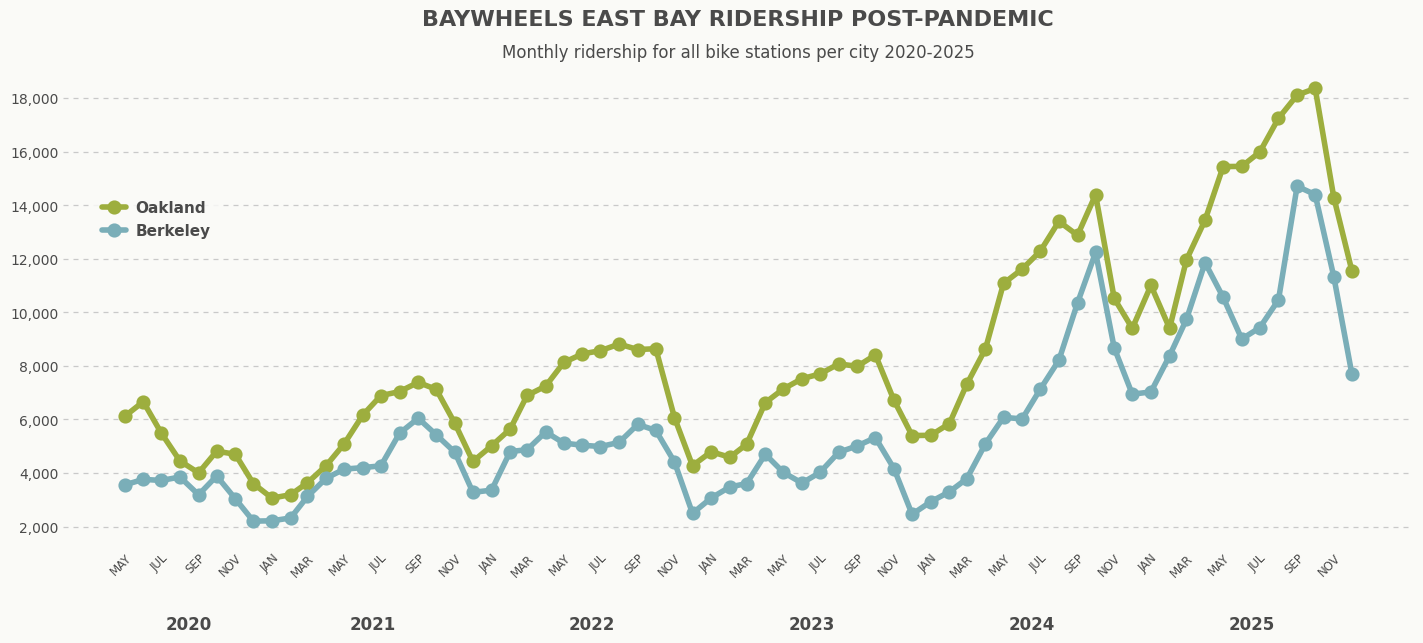

In [ ]:
# @title
# Style and Text
sns.set_style('white')
plt.rcParams.update({'font.family': 'DejaVu Sans'})

# Plot
fig, ax = plt.subplots(figsize=(15, 6.8))
fig.patch.set_facecolor(ground)
ax.set_facecolor(ground)

# Line Style
sns.lineplot(
    data=bw_monthly_ridership[bw_monthly_ridership.start_city == 'Oakland'],
    x='date', y='rides',
    color=oakland,
    linewidth=4,
    marker='o',
    markersize=8,
    markerfacecolor=oakland,
    markeredgecolor=oakland,
    markeredgewidth=2.2,
    label='Oakland', ax=ax, zorder=3,
)
sns.lineplot(
    data=bw_monthly_ridership[bw_monthly_ridership.start_city == 'Berkeley'],
    x='date', y='rides',
    color=berkeley,
    linewidth=4,
    marker='o',
    markersize=8,
    markerfacecolor=berkeley,
    markeredgecolor=berkeley,
    markeredgewidth=2.2,
    label='Berkeley', ax=ax, zorder=3,
)

# Y - Axis
ax.yaxis.grid(True,
              linestyle='--',
              color=grid,
              linewidth=0.9,
              dashes=(4, 4))
ax.xaxis.grid(False)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_ylabel('')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='y',
               length=0,
               colors=text,
               labelsize=10)

# X - Axis
months = pd.date_range(start=bw_monthly_ridership.date.min(),
                       end=bw_monthly_ridership.date.max(), freq='MS')
ax.set_xticks(months)
labels = [d.strftime('%b').upper() if i % 2 == 0 else ''
          for i, d in enumerate(months)]
ax.set_xticklabels(labels,
                   fontsize=8.5,
                   color=text,
                   rotation=45,
                   ha='right',
                   rotation_mode='anchor')
ax.tick_params(axis='x',
               length=4,
               width=0.8,
               color=text, pad=2)
ax.set_xlabel('')
years = sorted({d.year for d in months})
ymin = ax.get_ylim()[0]
for yr in years:
    yr_months = [d for d in months if d.year == yr]
    center = yr_months[0] + (yr_months[-1] - yr_months[0]) / 2
    ax.annotate(
        str(yr),
        xy=(center, 0), xycoords=('data', 'axes fraction'),
        xytext=(0, -52), textcoords='offset points',
        ha='center',
        va='top',
        fontweight='bold',
        fontsize=12,
        color=text,
    )

# Title & Subtitle
ax.set_title(
    'BAYWHEELS EAST BAY RIDERSHIP POST-PANDEMIC',
    fontweight='bold',
    fontsize=16,
    color=text,
    loc='center',
    pad=30,
)
ax.text(
    0.5, 1.02, 'Monthly ridership for all bike stations per city 2020-2025',
    transform=ax.transAxes,
    ha='center',
    fontsize=12,
    color=text
)

# Legend
leg = ax.legend(
    loc='center left', bbox_to_anchor=(0.015, 0.68),
    frameon=True,
    fontsize=11,
    labelcolor=text,
    handlelength=1.6,
    handletextpad=0.6,
    borderpad=0.7,
)
leg_frame = leg.get_frame()
leg_frame.set_facecolor(ground)
leg_frame.set_edgecolor('none')
leg_frame.set_alpha(0.85)
for text_obj, color in zip(leg.get_texts(), [oakland, berkeley]):
    text_obj.set_fontweight('bold')

# Display
plt.subplots_adjust(left=0.07, right=0.97, top=0.90, bottom=0.20)
# Save Image
plt.savefig("Ridership Trends.jpg", dpi=300, bbox_inches='tight')

plt.show()

## Median Trip Duration Profile

In [ ]:
# Data Processing for Trip Duration Profile
all_trips = (trip_quantiles[['median']]
           .reset_index()
           .rename(columns={'median': 'duration'}))
all_trips['category'] = 'All Bike Trips'
classic_duration = (classic_trip_quantiles[['median']]
               .reset_index()
               .rename(columns={'median': 'duration'}))
classic_duration['category'] = 'Classic Bike Trips'
durations = pd.concat([all_trips, classic_duration], ignore_index=True)
durations['year'] = durations['year'].astype(int)

In [ ]:
# Reassign color variables for new graph
ground = '#fafaf7'
grid = '#c9c9c9'
med_text = '#4a4a4a'
all_bikes = '#9dae3e'
classic_bikes = '#7aaeb8'

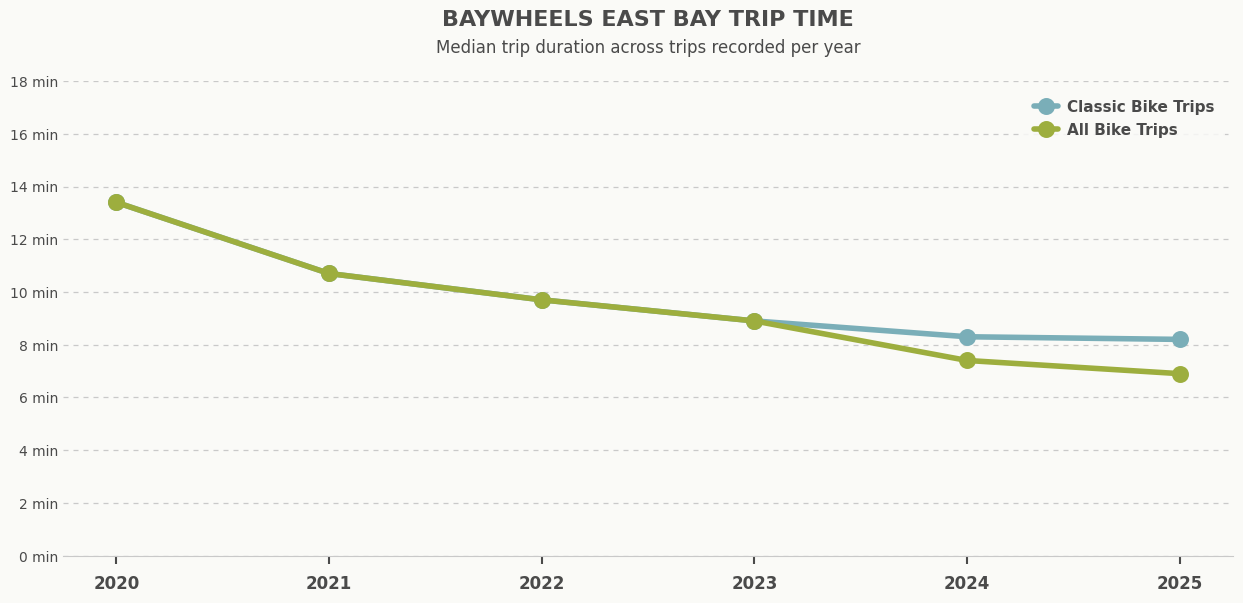

In [ ]:
# @title
# Style
sns.set_style('white')
plt.rcParams.update({'font.family': 'DejaVu Sans'})

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor(ground)
ax.set_facecolor(ground)

# Line Plot
sns.lineplot(
    data=durations[durations['category'] == 'Classic Bike Trips'],
    x='year',
    y='duration',
    color=classic_bikes,
    linewidth=4,
    marker='o',
    markersize=10,
    markerfacecolor=classic_bikes,
    markeredgecolor=classic_bikes,
    markeredgewidth=2.2,
    label='Classic Bike Trips',
    ax=ax,
    zorder=3,
)
sns.lineplot(
    data=durations[durations['category'] == 'All Bike Trips'],
    x='year',
    y='duration',
    color=all_bikes,
    linewidth=4,
    marker='o',
    markersize=10,
    markerfacecolor=all_bikes,
    markeredgecolor=all_bikes,
    markeredgewidth=2.2,
    label='All Bike Trips',
    ax=ax,
    zorder=4,
)

# Grid and Spines
ax.yaxis.grid(True, linestyle='--',
              color=grid,
              linewidth=0.9,
              dashes=(4, 4))
ax.xaxis.grid(False)
ax.set_axisbelow(True)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color(grid)

# Y-Axis
ax.set_ylim(0, 18)
ax.set_ylabel('')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f} min'))
ax.tick_params(axis='y',
               length=0,
               colors=text,
               labelsize=10)

# X-Axis
years = sorted(durations['year'].unique())
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years],
                   fontsize=12,
                   color=med_text,
                   fontweight='bold')
ax.tick_params(axis='x',
               which='major',
               bottom=True,
               length=6,
               width=1.5,
               color=med_text,
               pad=8)
ax.set_xlabel('')

# Title
ax.set_title(
    'BAYWHEELS EAST BAY TRIP TIME',
    fontweight='bold',
    fontsize=16,
    color=med_text,
    loc='center',
    pad=40,
)
ax.text(
    0.5, 1.06, 'Median trip duration across trips recorded per year',
    transform=ax.transAxes,
    ha='center',
    fontsize=12,
    color=text
)

# Legend
leg = ax.legend(
    loc='upper right', frameon=True,
    fontsize=11,
    labelcolor=med_text,
    handlelength=1.6,
    handletextpad=0.6,
    borderpad=0.7,
)
leg_frame = leg.get_frame()
leg_frame.set_facecolor(ground)
leg_frame.set_edgecolor('none')
leg_frame.set_alpha(0.85)
for text_obj in leg.get_texts():
    text_obj.set_fontweight('bold')

# Display
plt.subplots_adjust(left=0.07, right=0.97, top=0.88, bottom=0.15)
plt.savefig("Median Trip Duration.jpg", dpi=300, bbox_inches='tight')

plt.show()

## E-Bike Waffle Chart

After demonstrating the effect E-Bikes have on median trip duration, the subsequent graphic visualizes the magnitude of the E-Bike shift across the East Bay system.

In [ ]:
# Data Processing for Chart
recent_yr = baywheels_eb[baywheels_eb['year'].isin([2024, 2025])]
type_counts = (recent_yr
          .groupby(['year', 'bike_type'], observed=True)
          .size()
          .unstack(fill_value=0))
type_shares = type_counts.div(type_counts.sum(axis=1), axis=0) * 100

years_data = {}
for yr in [2024, 2025]:
    classic_pct = int(round(type_shares.loc[yr, 'classic']))
    years_data[yr] = {
        'classic_pct': classic_pct,
        'electric_pct': 100 - classic_pct,
        'total': int(type_counts.loc[yr].sum()),
    }

In [ ]:
# Reassign color variables for graph
ground = '#fafaf7'
grid = '#c9c9c9'
waffle_text = '#4a4a4a'
subtext = '#7a7a7a'
classic = '#7aaeb8'
electric = '#9dae3e'

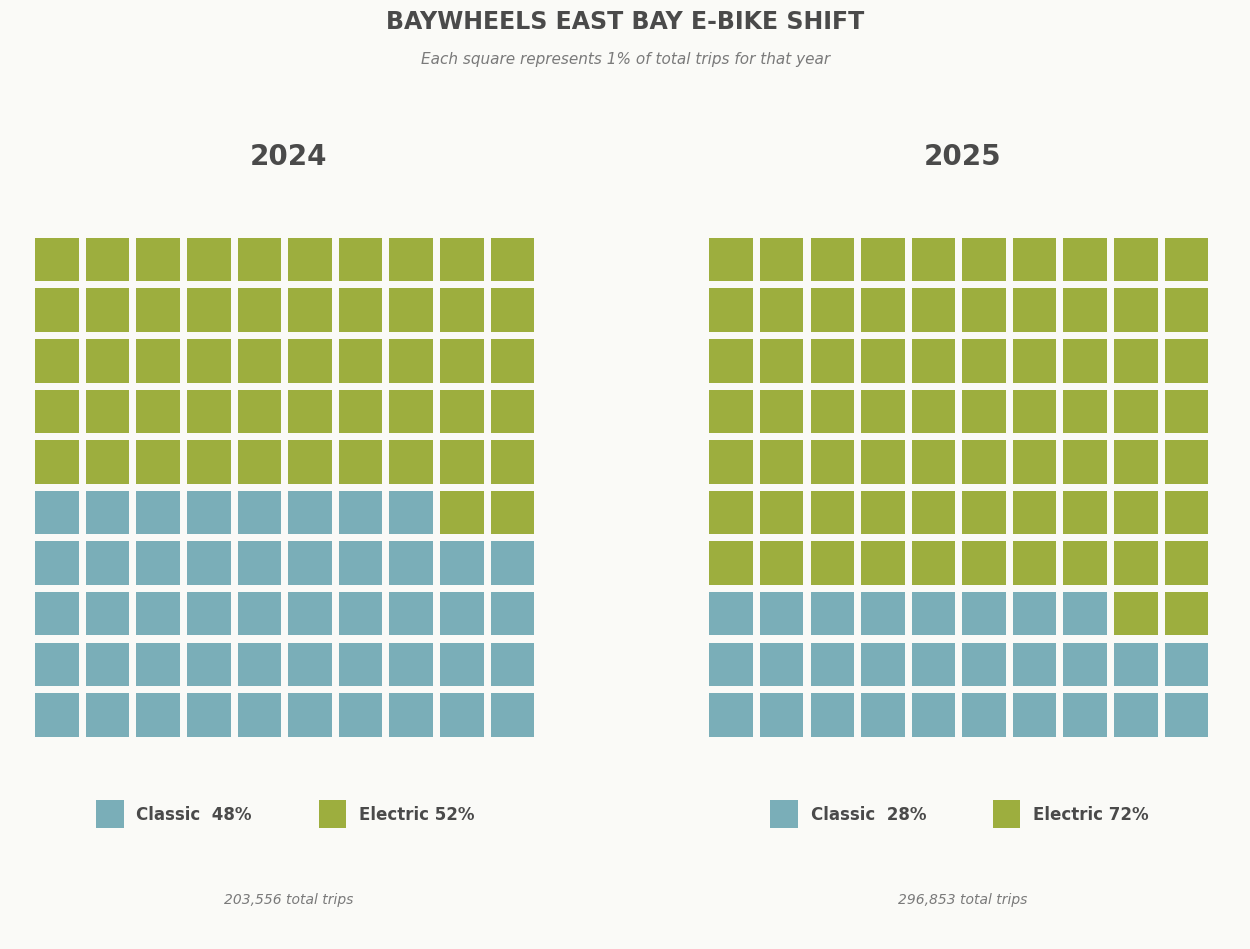

In [ ]:
# @title
# Style
sns.set_style('white')
plt.rcParams.update({'font.family': 'DejaVu Sans'})

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
fig.patch.set_facecolor(ground)
square = 0.86
for ax, yr in zip(axes, [2024, 2025]):
    ax.set_facecolor(ground)
    data = years_data[yr]
    classic_pct = data['classic_pct']
    for i in range(100):   # Waffles
        row = i // 10
        col = i % 10
        color = classic if i < classic_pct else electric
        ax.add_patch(Rectangle(
            (col, row),
            square, square,
            facecolor=color,
            edgecolor='none',
        ))
    # Year Label
    ax.text(5, 11.2,
            str(yr),
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=20,
            color=waffle_text)
    # Legend
    swatch_y = -1.8
    sw = 0.55
    ax.add_patch(Rectangle((1.2, swatch_y), sw, sw,
                           facecolor=classic,
                           edgecolor='none'))

    ax.text(1.2 + sw + 0.25, swatch_y + sw / 2,
            f"Classic  {data['classic_pct']}%",
            ha='left',
            va='center',
            fontsize=12,
            color=waffle_text,
            fontweight='bold')
    ax.add_patch(Rectangle((5.6, swatch_y), sw, sw,
                           facecolor=electric,
                           edgecolor='none'))
    ax.text(5.6 + sw + 0.25, swatch_y + sw / 2,
            f"Electric {data['electric_pct']}%",
            ha='left', va='center',
            fontsize=12,
            color=waffle_text,
            fontweight='bold')
    # Footnote
    ax.text(5, -3.2, f"{data['total']:,} total trips",
            ha='center',
            va='center',
            fontsize=10,
            color=subtext,
            style='italic')
    # Axis
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-4, 13)
    ax.set_aspect('equal')
    ax.axis('off')
# Title
fig.suptitle('BAYWHEELS EAST BAY E-BIKE SHIFT',
             fontweight='bold',
             fontsize=17,
             color=waffle_text,
             y=0.96)
fig.text(0.5, 0.91,
         'Each square represents 1% of total trips for that year',
         ha='center',
         va='center',
         fontsize=11,
         color=subtext,
         style='italic')

# Display
plt.subplots_adjust(top=0.89, bottom=0.03, left=0.03, right=0.97, wspace=0.05)
plt.savefig("E-Bike Shift.jpg", dpi=300, bbox_inches='tight')

plt.show()

## BART Volume Chart

Chart to conclude the mobility patterns section of the project, transitions into analyzing ridership on a neighborhood level to discuss disparities in infrastructure investment.

In [ ]:
# Data processing for BART chart

bart_rides = baywheels_eb[baywheels_eb['bart_trip'] == 'BART']
bart_starts = bart_rides.groupby('start_station_name').size()
bart_ends = bart_rides.groupby('end_station_name').size()
bart_station_totals = bart_starts.add(bart_ends, fill_value=0).reset_index()
bart_station_totals.columns = ['station_name', 'total_rides']
bart_station_totals = bart_station_totals[bart_station_totals['station_name'].str.contains('BART', case=False)]

bart_station_totals = bart_station_totals[bart_station_totals['station_name'] != 'West Oakland BART Station'] # Data cleaning error from earlier.
bart_station_totals['station_name'] = bart_station_totals['station_name'].str.replace(' Station', '', case=False).str.strip()
bart_station_totals = bart_station_totals.sort_values('total_rides', ascending=False)

display(bart_station_totals)

,station_name,total_rides
88,MacArthur BART,61163
53,Downtown Berkeley BART,54643
8,19th Street BART,45178
108,Rockridge BART,36244
82,Lake Merritt BART,35223
133,West Oakland BART,32422
31,Ashby BART,28918
103,North Berkeley BART,18741
67,Fruitvale BART,3642


In [ ]:
# Reassign color variables for graph
ground = '#fafaf7'
grid = '#c9c9c9'
bart_text = '#3a3a3a'
subtext = '#909090'
emphasis = {'MacArthur BART', 'Fruitvale BART'}
emph_color = '#1f4e79'
muted_color = '#c5d1dd'

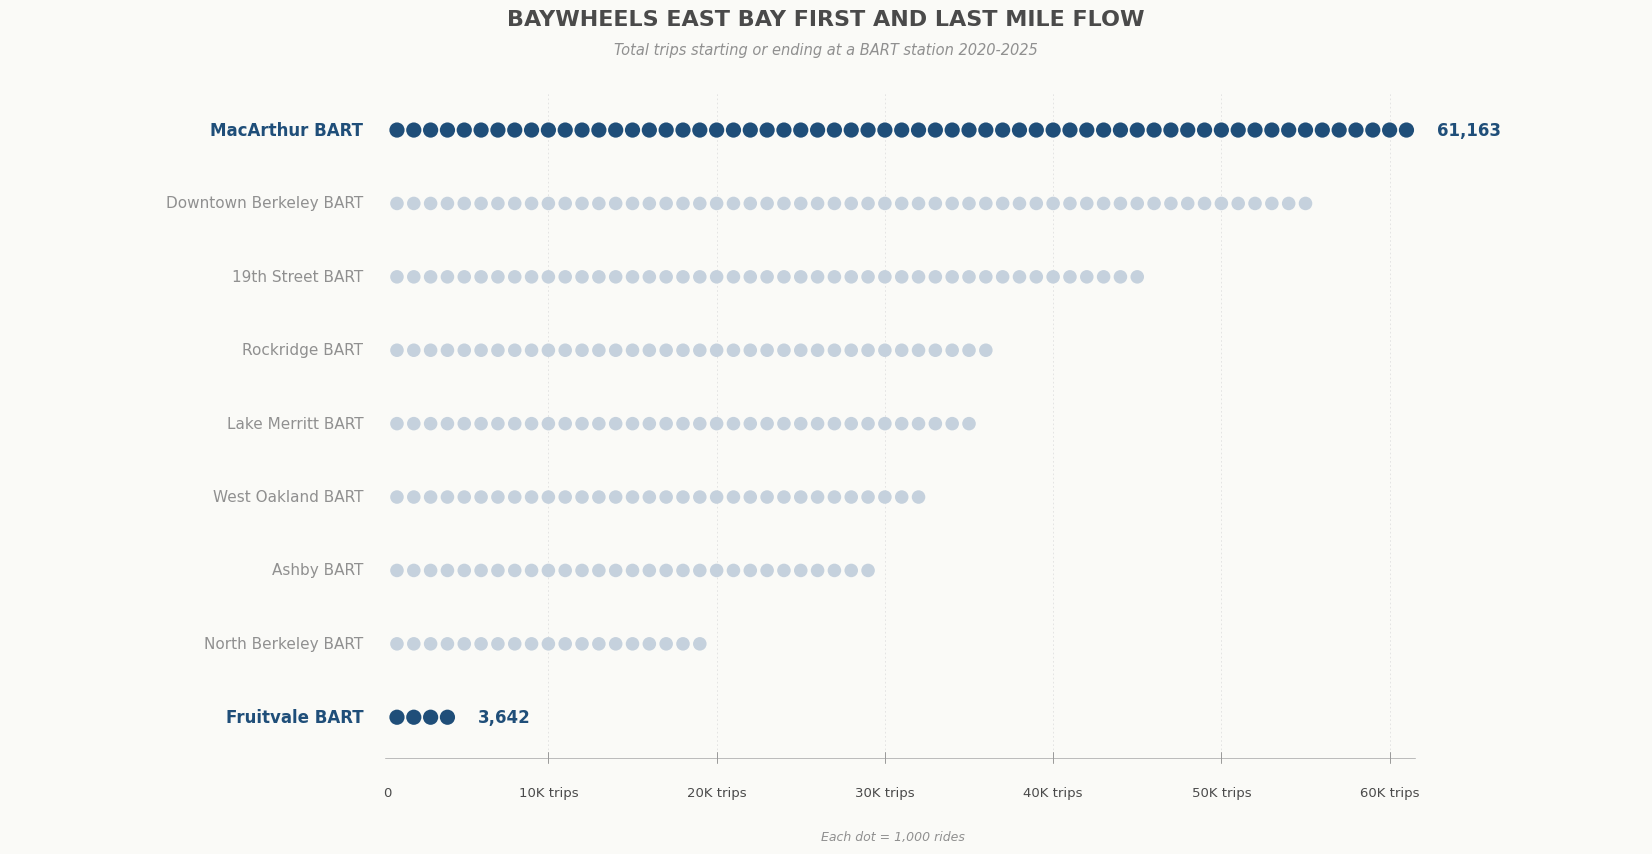

In [ ]:
# @title
# Style
sns.set_style("white")
plt.rcParams.update({'font.family': 'DejaVu Sans'})
dots = 1000

# Chart

fig, ax = plt.subplots(figsize=(17, 9))
fig.patch.set_facecolor(ground)
ax.set_facecolor(ground)

max_dots = int(round(bart_station_totals['total_rides'].max() / dots))
bounds = len(bart_station_totals)

# Plot area
top_y = bounds - 0.5
base_y = -0.55
label_y = -0.95

# Dots
for x_ref in range(10, max_dots + 1, 10):
    ax.plot([x_ref, x_ref], [base_y, top_y],
            color='#e0e0e0',
            linewidth=0.6,
            linestyle=(0, (2, 3)),
            zorder=1)

for i, (station_name, total) in enumerate(bart_station_totals.set_index('station_name')['total_rides'].items()):
    y = bounds - 1 - i
    n_dots = int(round(total / dots))
    is_emph = station_name in emphasis
    color = emph_color if is_emph else muted_color

    ax.scatter(
        range(1, n_dots + 1), [y] * n_dots,
        s=120 if is_emph else 95,
        color=color,
        edgecolors='none',
        zorder=4 if is_emph else 2,
    )

    ax.text(
        -1.0, y, station_name,
        ha='right',
        va='center',
        fontsize=12 if is_emph else 11,
        fontweight='bold' if is_emph else 'normal',
        color=emph_color if is_emph else subtext,
    )

    if is_emph:
        ax.text(
            n_dots + 1.8, y, f"{total:,}",
            ha='left',
            va='center',
            fontsize=12,
            color=color,
            fontweight='bold',
        )

# X-Axis
ax.plot([0.3, max_dots + 0.5], [base_y, base_y],
        color='#BBBBBB',
        linewidth=0.7,
        zorder=2)

# Tick marks
for x_val in range(10, max_dots + 1, 10):
    ridership_val = x_val * dots
    ax.plot([x_val, x_val], [base_y - 0.08, base_y + 0.08],
            color='#999999',
            linewidth=0.7,
            zorder=3)
    ax.text(x_val, label_y, f"{ridership_val // 1000}K trips",
            ha='center',
            va='top',
            fontsize=9.5,
            color=text)

ax.text(0.4, label_y, "0",
        ha='center',
        va='top',
        fontsize=9.5,
        color=text)

ax.set_xlim(-22, max_dots + 14)
ax.set_ylim(-1.7, bounds - 0.4)
ax.axis('off')

# Title and Labels
ax.text(max_dots / 2, -1.55, 'Each dot = 1,000 rides',
        ha='center',
        va='top',
        fontsize=9,
        color=subtext,
        style='italic')

fig.suptitle('BAYWHEELS EAST BAY FIRST AND LAST MILE FLOW',
             fontweight='bold',
             fontsize=16,
             color=text,
             y=0.965)
fig.text(0.5, 0.92,
         'Total trips starting or ending at a BART station 2020-2025',
         ha='center',
         va='center',
         fontsize=10.5,
         color=subtext,
         style='italic')

# Display
plt.subplots_adjust(top=0.88, bottom=0.04, left=0.02, right=0.98)
plt.savefig("BART Trips.jpg", dpi=300, bbox_inches='tight')

plt.show()